In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

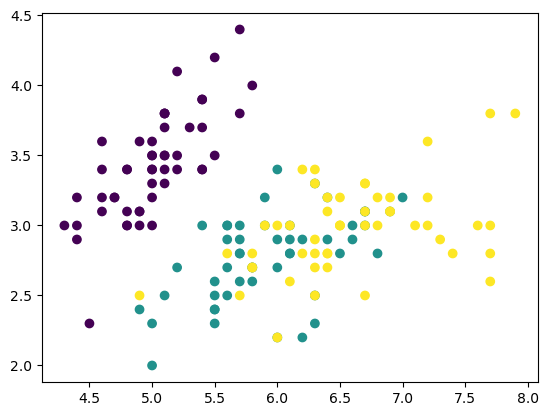

In [27]:
iris = load_iris()
x = iris.data
y = iris.target
x.shape
plt.scatter(x[:, 0],x[:, 1], c = y)

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 5 )
print(f"train sets : {x_train.shape}")
print(f"train sets : {x_test.shape}")

train sets : (120, 4)
train sets : (30, 4)


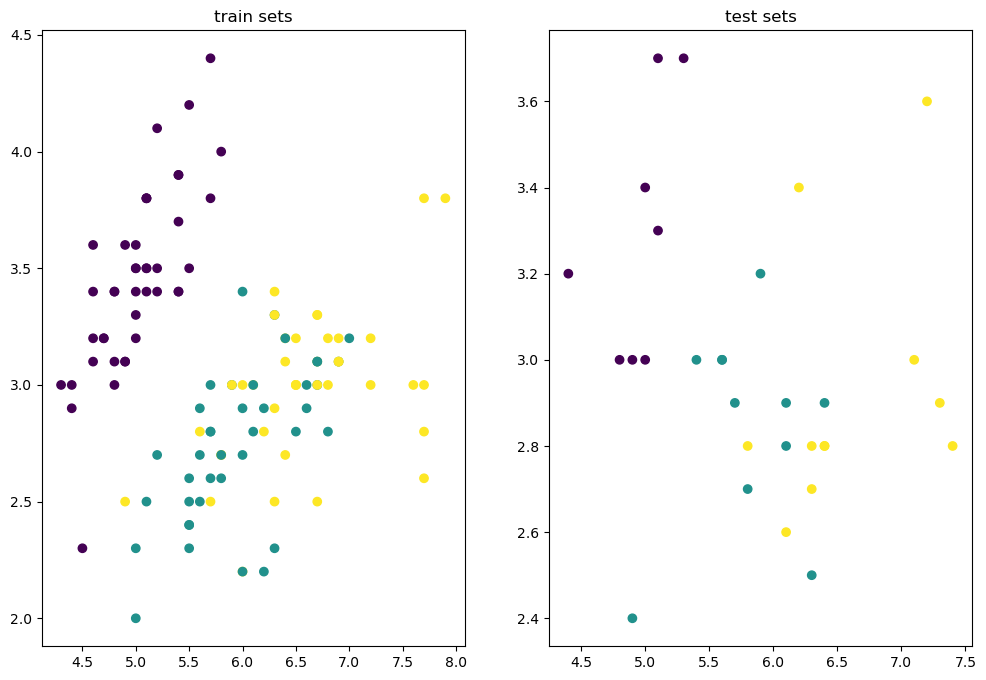

In [30]:
plt.figure(figsize = (12, 8))
plt.subplot(1,2,1)
plt.scatter(x_train[:, 0], x_train[:, 1], c = y_train)
plt.title("train sets")
plt.subplot(1,2,2)
plt.scatter(x_test[:, 0], x_test[:, 1], c = y_test)
plt.title("test sets")
plt.show()

In [31]:
from sklearn.neighbors import KNeighborsClassifier

In [32]:
model = KNeighborsClassifier(n_neighbors = 6)
model.fit(x_train, y_train)
print(f"train score : {model.score(x_train, y_train)}")
print(f"test score : {model.score(x_test, y_test)}")

train score : 0.9833333333333333
test score : 0.9666666666666667


In [33]:
from sklearn.model_selection import cross_val_score

In [34]:
cross_val_score(KNeighborsClassifier(8), x_train, y_train, cv=5, scoring = "accuracy").mean()

np.float64(0.9666666666666668)

In [35]:
from sklearn.model_selection import validation_curve

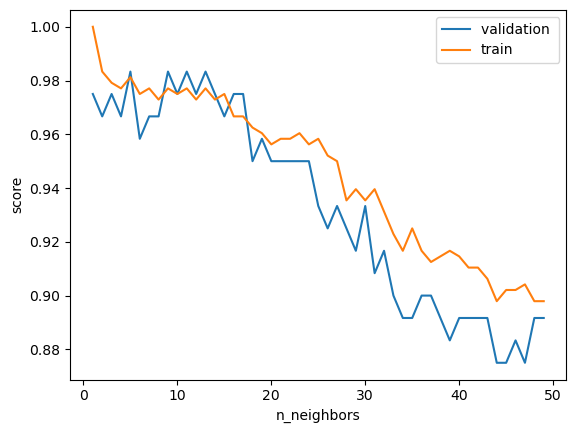

In [37]:
model = KNeighborsClassifier()
k = np.arange(1, 50)
train_score, val_score = validation_curve(model, x_train, y_train, param_name = "n_neighbors", param_range = k, cv = 5)
plt.plot(k, val_score.mean(axis =1), label = "validation ")
plt.plot(k, train_score.mean(axis = 1), label = "train")
plt.legend()
plt.xlabel("n_neighbors")
plt.ylabel("score")
plt.show()
         